In [23]:
import polars as pl

In [24]:
data_std = pl.read_csv("data/ตัวอย่างชุดข้อมูลสำหรับ Correlation, Data Conversion, Missing Value และ K-mean Clustering สำหรับ Rapidminer/data_student.csv")
data_std.head()

ID,STG,SCG,STR,LPR,PEG,UNS
i64,f64,f64,f64,f64,f64,i64
1,0.0,0.0,0.0,0.0,0.0,0
2,0.08,0.08,0.1,0.24,0.9,3
3,0.06,0.06,0.05,0.25,0.33,1
4,0.1,0.1,0.15,0.65,0.3,2
5,0.08,0.08,0.08,0.98,0.24,1


In [25]:
schema_overrides = {
	'Loan_ID': pl.Utf8,
	'Gender': pl.Utf8,
	'Married': pl.Utf8,
	'Dependents': pl.Utf8,
	'Education': pl.Utf8,
	'Self_Employed': pl.Utf8,
	'ApplicantIncome': pl.Int64,
	'CoapplicantIncome': pl.Float64,
	'LoanAmount': pl.Float64,
	'Loan_Amount_Term': pl.Float64,
	'Credit_History': pl.Float64,
	'Property_Area': pl.Utf8,
	'Loan_Status': pl.Utf8
}

data_loan = pl.read_csv(
	"data/ตัวอย่างชุดข้อมูลสำหรับ Correlation, Data Conversion, Missing Value และ K-mean Clustering สำหรับ Rapidminer/Loan_Dataset.csv",
	schema_overrides=schema_overrides
)
data_loan.head()

Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
str,str,str,str,str,str,i64,f64,f64,f64,f64,str,str
"""LP001002""","""Male""","""No""","""0""","""Graduate""","""No""",5849,0.0,null,360.0,1.0,"""Urban""","""Y"""
"""LP001003""","""Male""","""Yes""","""1""","""Graduate""","""No""",4583,1508.0,128.0,360.0,1.0,"""Rural""","""N"""
"""LP001005""","""Male""","""Yes""","""0""","""Graduate""","""Yes""",3000,0.0,66.0,360.0,1.0,"""Urban""","""Y"""
"""LP001006""","""Male""","""Yes""","""0""","""Not Graduate""","""No""",2583,2358.0,120.0,360.0,1.0,"""Urban""","""Y"""
"""LP001008""","""Male""","""No""","""0""","""Graduate""","""No""",6000,0.0,141.0,360.0,1.0,"""Urban""","""Y"""


In [26]:
# inspect the data information
data_loan.describe()

statistic,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,str
"""count""","""614""","""601""","""611""","""599""","""614""","""582""",614.0,614.0,592.0,600.0,564.0,"""614""","""614"""
"""null_count""","""0""","""13""","""3""","""15""","""0""","""32""",0.0,0.0,22.0,14.0,50.0,"""0""","""0"""
"""mean""",null,null,null,null,null,null,5403.459283,1621.245798,146.412162,342.0,0.842199,null,null
"""std""",null,null,null,null,null,null,6109.041673,2926.248369,85.587325,65.12041,0.364878,null,null
"""min""","""LP001002""","""Female""","""No""","""0""","""Graduate""","""No""",150.0,0.0,9.0,12.0,0.0,"""Rural""","""N"""
"""25%""",null,null,null,null,null,null,2876.0,0.0,100.0,360.0,1.0,null,null
"""50%""",null,null,null,null,null,null,3813.0,1210.0,128.0,360.0,1.0,null,null
"""75%""",null,null,null,null,null,null,5800.0,2302.0,168.0,360.0,1.0,null,null
"""max""","""LP002990""","""Male""","""Yes""","""3+""","""Not Graduate""","""Yes""",81000.0,41667.0,700.0,480.0,1.0,"""Urban""","""Y"""


In [27]:
# Missing Value Handling
loan_impute = data_loan.with_columns([
	pl.col('Gender').fill_null(data_loan['Gender'].drop_nulls().mode()),
    pl.col('Married').fill_null(data_loan['Married'].drop_nulls().mode()),
    pl.col('Dependents').fill_null(data_loan['Dependents'].drop_nulls().mode()),
    pl.col('Self_Employed').fill_null(data_loan['Self_Employed'].drop_nulls().mode()),
    pl.col('LoanAmount').fill_null(data_loan['LoanAmount'].drop_nulls().mean()),
    pl.col('Loan_Amount_Term').fill_null(data_loan['Loan_Amount_Term'].drop_nulls().mean()),
    pl.col('Credit_History').fill_null(data_loan['Credit_History'].drop_nulls().mode()),
    pl.col('Property_Area').fill_null(data_loan['Property_Area'].drop_nulls().mode()),
])
loan_impute.describe()

statistic,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,str
"""count""","""614""","""614""","""614""","""614""","""614""","""614""",614.0,614.0,614.0,614.0,614.0,"""614""","""614"""
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""","""0"""
"""mean""",null,null,null,null,null,null,5403.459283,1621.245798,146.412162,342.0,0.855049,null,null
"""std""",null,null,null,null,null,null,6109.041673,2926.248369,84.037468,64.372489,0.352339,null,null
"""min""","""LP001002""","""Female""","""No""","""0""","""Graduate""","""No""",150.0,0.0,9.0,12.0,0.0,"""Rural""","""N"""
"""25%""",null,null,null,null,null,null,2876.0,0.0,100.0,360.0,1.0,null,null
"""50%""",null,null,null,null,null,null,3813.0,1210.0,129.0,360.0,1.0,null,null
"""75%""",null,null,null,null,null,null,5800.0,2302.0,165.0,360.0,1.0,null,null
"""max""","""LP002990""","""Male""","""Yes""","""3+""","""Not Graduate""","""Yes""",81000.0,41667.0,700.0,480.0,1.0,"""Urban""","""Y"""


In [30]:
# Data Conversion string to ordinal to numerical
loan_impute = loan_impute.with_columns([
    pl.col('Dependents').
])

Self_Employed,count
str,u32
"""Yes""",82
"""No""",532


In [19]:
# Selcting columns as numerical and categorical
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
categorical = [ col for col in data_loan.columns if col not in numerical_cols]

shape: (4, 4)
┌─────────────────┬───────────────────┬────────────┬──────────────────┐
│ ApplicantIncome ┆ CoapplicantIncome ┆ LoanAmount ┆ Loan_Amount_Term │
│ ---             ┆ ---               ┆ ---        ┆ ---              │
│ f64             ┆ f64               ┆ f64        ┆ f64              │
╞═════════════════╪═══════════════════╪════════════╪══════════════════╡
│ 1.0             ┆ -0.116605         ┆ 0.56562    ┆ -0.045242        │
│ -0.116605       ┆ 1.0               ┆ 0.187828   ┆ -0.059675        │
│ 0.56562         ┆ 0.187828          ┆ 1.0        ┆ 0.038801         │
│ -0.045242       ┆ -0.059675         ┆ 0.038801   ┆ 1.0              │
└─────────────────┴───────────────────┴────────────┴──────────────────┘


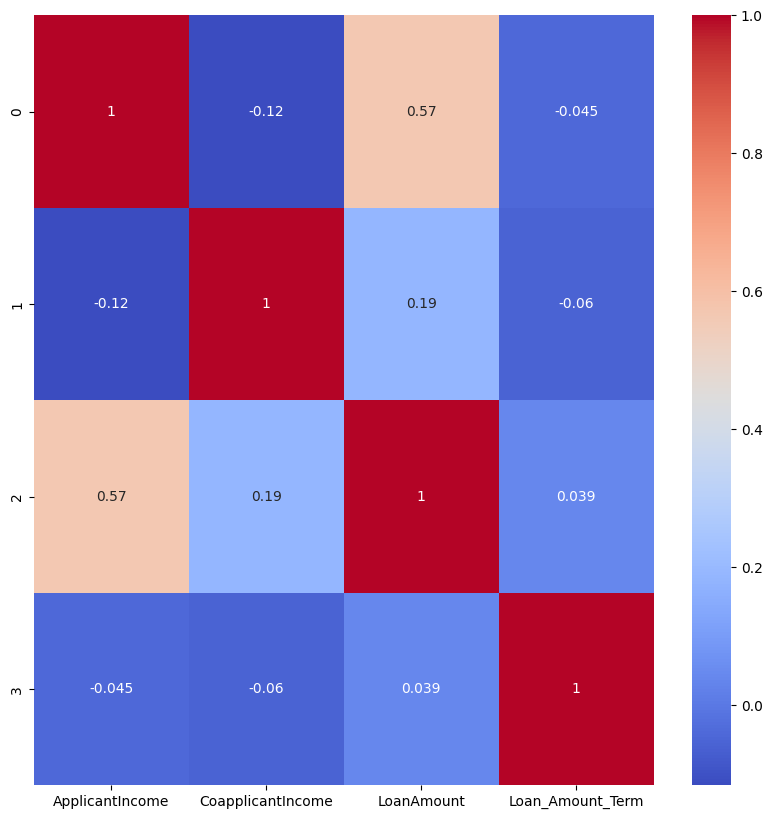

In [22]:
# Display Correlation Matrix
correlation_matrix = data_loan.select(numerical_cols).corr()
print(correlation_matrix)
# Visualize Correlation Matrix via Heatmap using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix.to_pandas(), annot=True, cmap="coolwarm")
plt.show()